In [1]:
# ============================================================
# 🚀 ROCKET LAUNCH PREDICTOR
# SpaceX Falcon 9 Booster Landing Success
# Built by: Kartik | Munich | 2025
# Goal: Predict landing failures to prevent $60M losses!
# Using: Pipeline + Feature Engineering + SVM + XGBoost
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (StandardScaler,
                                    OneHotEncoder,
                                    LabelEncoder)
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (train_test_split,
                                      cross_val_score,
                                      StratifiedKFold,
                                      GridSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score,
                              precision_score,
                              recall_score, f1_score,
                              roc_auc_score,
                              confusion_matrix,
                              classification_report,
                              roc_curve)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')
plt.style.use('dark_background')

print("✅ Libraries imported!")
print("🚀 Rocket Launch Predictor ready!")
print("🎯 Goal: Predict failures → save $60M per launch!")

✅ Libraries imported!
🚀 Rocket Launch Predictor ready!
🎯 Goal: Predict failures → save $60M per launch!


🚀 SPACEX FALCON 9 DATASET
   Total launches : 90
   Total features : 18

 LANDING OUTCOME:
  ✅ Success (1): 60 launches(66.7%)
 ❌Failure (0): 30 launches(33.3%)

 ALL FEATURES:
  FlightNumber         -> int64 | sample: 1
  Date                 -> object | sample: 2010-06-04
  BoosterVersion       -> object | sample: Falcon 9
  PayloadMass          -> float64 | sample: 6104.959411764706
  Orbit                -> object | sample: LEO
  LaunchSite           -> object | sample: CCAFS SLC 40
  Outcome              -> object | sample: None None
  Flights              -> int64 | sample: 1
  GridFins             -> bool | sample: False
  Reused               -> bool | sample: False
  Legs                 -> bool | sample: False
  LandingPad           -> object | sample: nan
  Block                -> float64 | sample: 1.0
  ReusedCount          -> int64 | sample: 0
  Serial               -> object | sample: B0003
  Longitude            -> float64 | sample: -80.577366
  Latitude             -> f

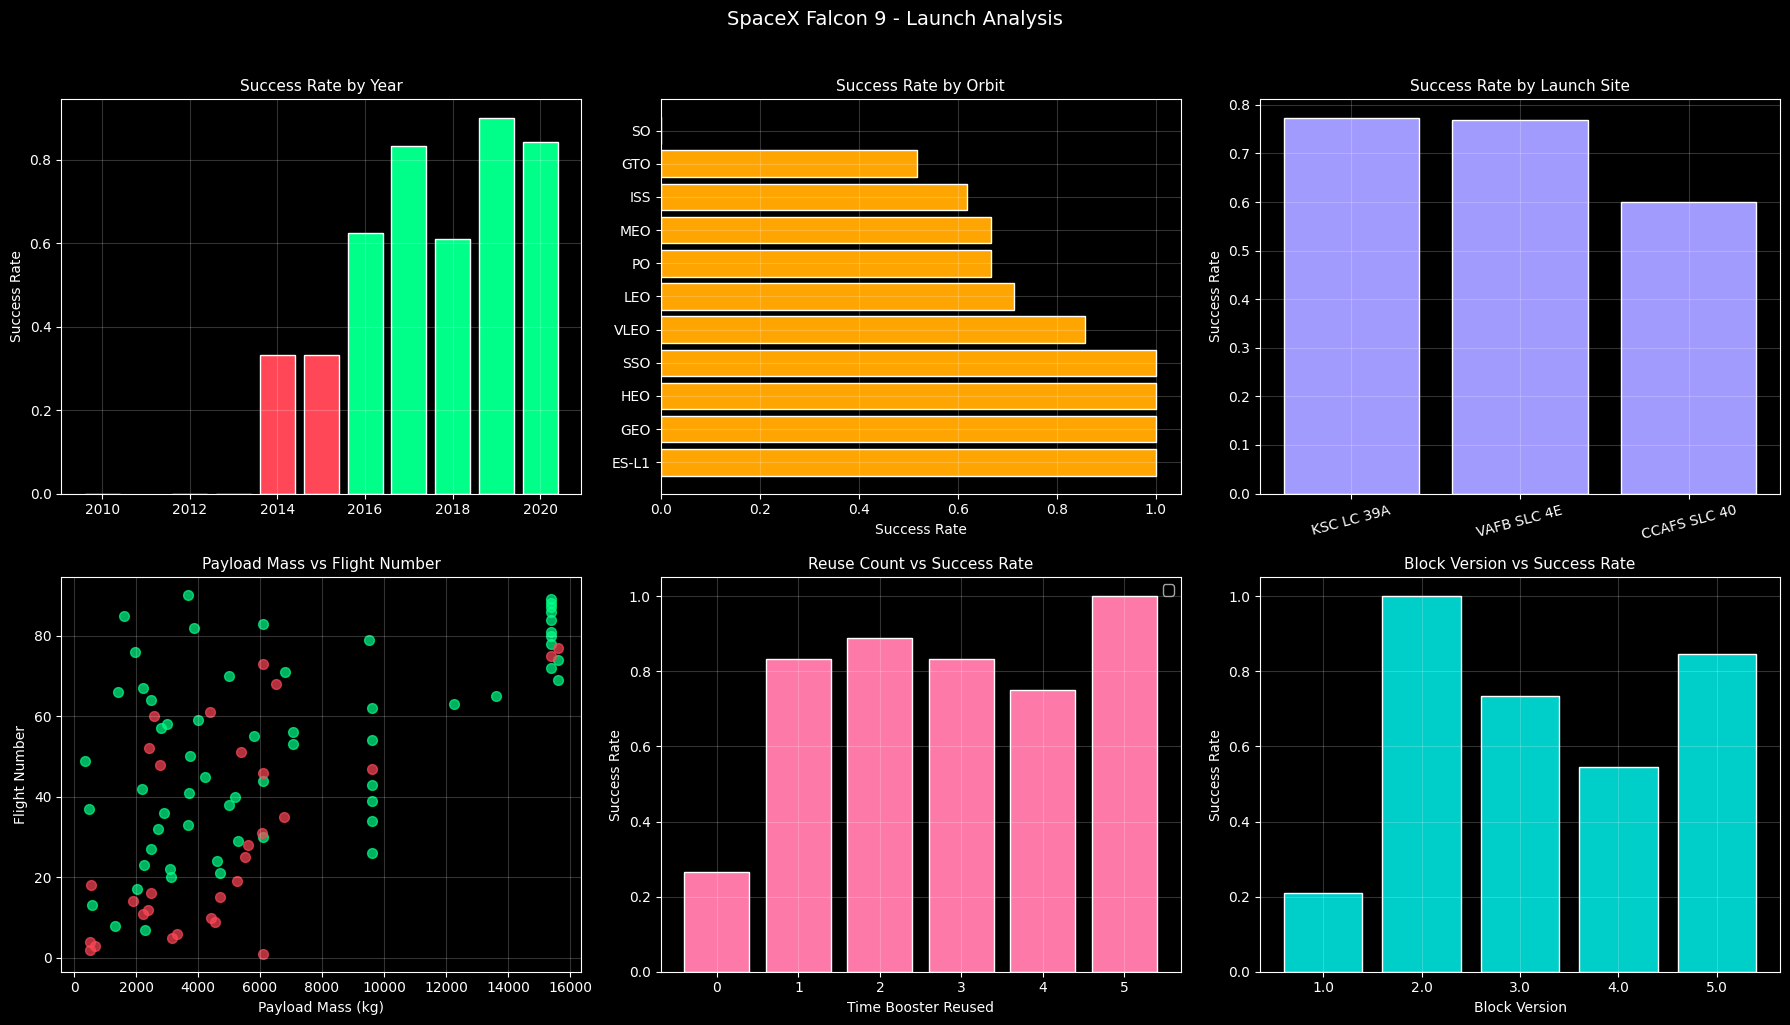

In [2]:
# ============================================================
# CELL 2: Load & Explore Data
# ============================================================

df = pd.read_csv('dataset_part_2.csv')

print("🚀 SPACEX FALCON 9 DATASET")
print("=" * 60)
print(f"   Total launches : {df.shape[0]}")
print(f"   Total features : {df.shape[1]}")
print("=" * 60)

#Target Breakdown
counts = df['Class'].value_counts() 
print(f"\n LANDING OUTCOME:")
print(f"  ✅ Success (1): {counts[1]} launches" f"({counts[1]/len(df)*100:.1f}%)")
print(f" ❌Failure (0): {counts[0]} launches" f"({counts[0]/len(df)*100:.1f}%)")

print(f"\n ALL FEATURES:")
for col in df.columns:
    print(f"  {col:20} -> {df[col].dtype}" f" | sample: {df[col].iloc[0]}") 

#Missing values
print(f"\n MISSING VALUES:")
missing = df.isnull().sum()
for col, val in missing[missing>0].items():
    print(f"  {col}: {val} missing")
if missing.sum() == 0:
    print("  None! Clean dataset")

#Key visualisations:
fig, axes = plt.subplots(2, 3, figsize=(18,10))


#Success rate over time
df['Year'] = pd.to_datetime(df['Date']).dt.year 
yearly = df.groupby('Year')['Class'].mean() 
axes[0][0].bar(yearly.index, yearly.values, color=['#ff4757' if v < 0.5 else '#00ff88' for v in yearly.values], edgecolor='white')
axes[0][0].set_title('Success Rate by Year', fontsize=11)
axes[0][0].set_ylabel('Success Rate')
axes[0][0].grid(alpha=0.2)

#Success by orbit
orbit_success = df.groupby('Orbit')['Class'].mean().sort_values(ascending=False)
axes[0][1].barh(orbit_success.index, orbit_success.values, color='#ffa502', edgecolor='white')
axes[0][1].set_title('Success Rate by Orbit', fontsize=11)
axes[0][1].set_xlabel('Success Rate')
axes[0][1].grid(alpha=0.2) 

#Success by launch site:
site_success = df.groupby('LaunchSite')['Class'].mean().sort_values(ascending=False)
axes[0][2].bar(site_success.index, site_success.values, color='#a29bfe', edgecolor='white')
axes[0][2].set_title('Success Rate by Launch Site', fontsize=11)
axes[0][2].set_ylabel('Success Rate')
axes[0][2].tick_params(axis='x', rotation=15)
axes[0][2].grid(alpha=0.2)

#Payload mass vs success
axes[1][0].scatter(
    df[df['Class']==1]['PayloadMass'],
    df[df['Class']==1]['FlightNumber'],
    color='#00ff88',alpha=0.7, s=50, label='Success')
axes[1][0].scatter(
    df[df['Class']==0]['PayloadMass'],
    df[df['Class']==0]['FlightNumber'],
    color='#ff4757', alpha=0.7, s=50, label='Failure')
axes[1][0].set_title('Payload Mass vs Flight Number', fontsize=11)
axes[1][0].set_xlabel('Payload Mass (kg)')
axes[1][0].set_ylabel('Flight Number')
axes[1][1].legend()
axes[1][0].grid(alpha=0.2)

#Reuse count vs success
reuse_success = df.groupby('ReusedCount')['Class'].mean()
axes[1][1].bar(reuse_success.index, reuse_success.values, color='#fd79a8', edgecolor='white')
axes[1][1].set_title('Reuse Count vs Success Rate', fontsize=11)
axes[1][1].set_xlabel('Time Booster Reused')
axes[1][1].set_ylabel('Success Rate')
axes[1][1].grid(alpha=0.2)

#Block version vs success
block_success = df.groupby('Block')['Class'].mean()
axes[1][2].bar(block_success.index.astype(str), block_success.values, color='#00cec9', edgecolor='white')
axes[1][2].set_title('Block Version vs Success Rate', fontsize=11)
axes[1][2].set_xlabel('Block Version')
axes[1][2].set_ylabel('Success Rate')
axes[1][2].grid(alpha=0.2)

plt.suptitle('SpaceX Falcon 9 - Launch Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show() 

In [5]:
# ============================================================
# CELL 3: Feature Engineering
# ============================================================

print("⚡ FEATURE ENGINEERING!")
print("=" * 60)

def engineer_rocket_features(df):
    df = df.copy()

    # Date features
    df['Date']       = pd.to_datetime(df['Date'])
    df['Year']       = df['Date'].dt.year
    df['Month']      = df['Date'].dt.month
    df['DayOfWeek']  = df['Date'].dt.dayofweek
    df['IsWeekend']  = (df['DayOfWeek'] >= 5).astype(int)

    # Experience features
    df['IsReused']   = df['Reused'].astype(int)
    df['HasGridFins']= df['GridFins'].astype(int)
    df['HasLegs']    = df['Legs'].astype(int)

    # Mission complexity
    df['PayloadMass']= df['PayloadMass'].fillna(
                       df['PayloadMass'].median())
    df['HeavyPayload']= (
        df['PayloadMass'] > 5000).astype(int)
    df['LightPayload']= (
        df['PayloadMass'] < 1000).astype(int)

    # Booster experience
    df['HighReuseCount'] = (
        df['ReusedCount'] > 2).astype(int)

    # Geographic features
    df['IsFloridaLaunch'] = (
        df['Latitude'] > 28).astype(int)

    # Block version (maturity)
    df['Block'] = df['Block'].fillna(
                  df['Block'].median())
    df['MatureBlock'] = (df['Block'] >= 5).astype(int)

    return df

df_eng = engineer_rocket_features(df)

new_features = ['Year', 'Month', 'DayOfWeek',
                'IsWeekend', 'IsReused', 'HasGridFins',
                'HasLegs', 'HeavyPayload', 'LightPayload',
                'HighReuseCount', 'IsFloridaLaunch',
                'MatureBlock']

print(f"   Original features  : {df.shape[1]-1}")
print(f"   Engineered features: {len(new_features)}")
print(f"   Total features     : {df_eng.shape[1]-1}")

print(f"\n✅ ENGINEERED FEATURES + SUCCESS RATE:")
for feat in new_features:
    try:
        corr = df_eng[feat].corr(df_eng['Class'])
        print(f"   {feat:20} → correlation={corr:+.3f}")
    except:
        pass

⚡ FEATURE ENGINEERING!
   Original features  : 18
   Engineered features: 12
   Total features     : 29

✅ ENGINEERED FEATURES + SUCCESS RATE:
   Year                 → correlation=+0.434
   Month                → correlation=+0.173
   DayOfWeek            → correlation=-0.011
   IsWeekend            → correlation=-0.018
   IsReused             → correlation=+0.208
   HasGridFins          → correlation=+0.643
   HasLegs              → correlation=+0.674
   HeavyPayload         → correlation=+0.047
   LightPayload         → correlation=-0.147
   HighReuseCount       → correlation=+0.309
   IsFloridaLaunch      → correlation=+nan
   MatureBlock          → correlation=+0.333


In [8]:
# ============================================================
# CELL 4: Build Pipeline & Train Models
# ============================================================

print("🚀 BUILDING PIPELINE & TRAINING!")
print("=" * 60)

#Drop columns causing leakage
drop_cols = ['FlightNumber', 'Date', 'Outcome', 'Serial', 'Class']

X = df_eng.drop(columns=drop_cols, errors='ignore') 
y = df_eng['Class']

#Separate numeric and categorical
num_cols = X.select_dtypes(
    include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'bool','category']).columns.tolist() 

print(f"   Numeric features    : {len(num_cols)}")
print(f"   Categorical features: {len(cat_cols)}")
print(f"   Categorical cols    : {cat_cols}") 

#Preprocessing pipelines:
num_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())
]) 

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore',
                               sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[('num', num_transformer, num_cols), ('cat', cat_transformer, cat_cols)
]) 

#Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y 
) 

print(f"\n✂️  SPLIT:")
print(f"   Training: {X_train.shape[0]} launches")
print(f"   Testing:  {X_test.shape[0]} launches")


#Build all model pipeline
model_pipes = {
    'Logistic Regression': Pipeline([
        ('prep', preprocessor),
        ('model', LogisticRegression(
            random_state=42, max_iter=1000, class_weight='balanced'
        ))
    ]),
    'Decision Tree': Pipeline([
        ('prep', preprocessor),
        ('model', DecisionTreeClassifier(
            random_state=42, max_depth=5, class_weight='balanced'
        ))
    ]),
    'Random Forest': Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1
        ))
    ]),
    'SVM (RBF)': Pipeline([
        ('prep', preprocessor),
        ('model', SVC(kernel='rbf', C=1.0, probability=True, random_state=42, class_weight='balanced'))
    ]),
    'XGBoost': Pipeline([
        ('prep', preprocessor),
        ('model', XGBClassifier(
            n_estimators=100, random_state=42, scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
            eval_metric='logloss',verbosity=0
        ))
    ]),
}

results = {} 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"\n{'Model':22} {'Train':8} {'Test':8}"
      f" {'Recall':8} {'AUC':8} {'CV Mean'}")
print("-" * 65)

for name, pipe in model_pipes.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1]

    train_acc = accuracy_score(y_train, pipe.predict(X_train))
    test_acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)
    cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')

    results[name] = {
        'pipe': pipe, 'train': train_acc,
        'test': test_acc, 'recall': recall,
        'auc': auc, 'cv': cv_scores.mean(),
        'y_pred': y_pred, 'y_proba': y_proba
    }

    print(f"{name:22} {train_acc:8.4f} {test_acc:8.4f}"
          f" {recall:8.4f} {auc:8.4f}"
          f" {cv_scores.mean():8.4f}")

best = max(results, key=lambda x: results[x]['auc'])
print(f"\n🏆 BEST MODEL: {best}")
print(f"   AUC:    {results[best]['auc']:.4f}")
print(f"   Recall: {results[best]['recall']:.4f}") 

🚀 BUILDING PIPELINE & TRAINING!
   Numeric features    : 18
   Categorical features: 7
   Categorical cols    : ['BoosterVersion', 'Orbit', 'LaunchSite', 'GridFins', 'Reused', 'Legs', 'LandingPad']

✂️  SPLIT:
   Training: 72 launches
   Testing:  18 launches

Model                  Train    Test     Recall   AUC      CV Mean
-----------------------------------------------------------------
Logistic Regression      0.9167   0.8889   0.9167   0.8472   0.8722
Decision Tree            0.9861   0.8333   1.0000   0.7292   0.7972
Random Forest            1.0000   0.8333   1.0000   0.9306   0.8958
SVM (RBF)                0.9167   0.7778   1.0000   0.8472   0.8556
XGBoost                  0.9722   0.8889   0.9167   0.9306   0.8889

🏆 BEST MODEL: Random Forest
   AUC:    0.9306
   Recall: 1.0000


In [9]:
# ============================================================
# CELL 5: Hyperparameter Tuning Best Model
# ============================================================

print("🎯 TUNING FOR MAXIMUM FAILURE DETECTION!")
print("=" * 60)

# Tune XGBoost (inside pipeline!)
xgb_params = {
    'model__n_estimators'    : [50, 100, 150, 200],
    'model__max_depth'       : [2, 3, 4, 5],
    'model__learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'model__subsample'       : [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'model__reg_alpha'       : [0, 0.1, 0.5, 1.0],
    'model__reg_lambda'      : [1, 1.5, 2.0],
}

from sklearn.model_selection import RandomizedSearchCV

xgb_search = RandomizedSearchCV(
    estimator=model_pipes['XGBoost'],
    param_distributions=xgb_params,
    n_iter=20,
    scoring='roc_auc',
    cv=cv, random_state=42,
    n_jobs=-1, verbose=1
)

xgb_search.fit(X_train, y_train)
best_model  = xgb_search.best_estimator_
y_pred_t    = best_model.predict(X_test)
y_proba_t   = best_model.predict_proba(X_test)[:,1]

tuned_acc   = accuracy_score(y_test, y_pred_t)
tuned_rec   = recall_score(y_test, y_pred_t,
              zero_division=0)
tuned_prec  = precision_score(y_test, y_pred_t,
              zero_division=0)
tuned_f1    = f1_score(y_test, y_pred_t,
              zero_division=0)
tuned_auc   = roc_auc_score(y_test, y_proba_t)

print(f"\n🏆 BEST PARAMETERS:")
for k, v in xgb_search.best_params_.items():
    print(f"   {k:35}: {v}")

print(f"\n📊 TUNED XGBOOST RESULTS:")
print(f"   Accuracy : {tuned_acc:.4f}")
print(f"   Recall   : {tuned_rec:.4f} ← failure detection!")
print(f"   Precision: {tuned_prec:.4f}")
print(f"   F1 Score : {tuned_f1:.4f}")
print(f"   AUC      : {tuned_auc:.4f}")
print(f"   CV AUC   : {xgb_search.best_score_:.4f}")

🎯 TUNING FOR MAXIMUM FAILURE DETECTION!
Fitting 5 folds for each of 20 candidates, totalling 100 fits

🏆 BEST PARAMETERS:
   model__subsample                   : 1.0
   model__reg_lambda                  : 2.0
   model__reg_alpha                   : 0.5
   model__n_estimators                : 50
   model__max_depth                   : 5
   model__learning_rate               : 0.1
   model__colsample_bytree            : 1.0

📊 TUNED XGBOOST RESULTS:
   Accuracy : 0.8889
   Recall   : 0.9167 ← failure detection!
   Precision: 0.9167
   F1 Score : 0.9167
   AUC      : 0.9167
   CV AUC   : 0.8983


🚀 ROCKET LANDING RESULTS:
   ✅ Failures correctly predicted : 5
   ✅ Successes correctly predicted: 11
   🚨 Failures MISSED              : 1
   ⚠️  False alarms                 : 1

   Failure catch rate: 83.33% ← saving $60M per caught failure!


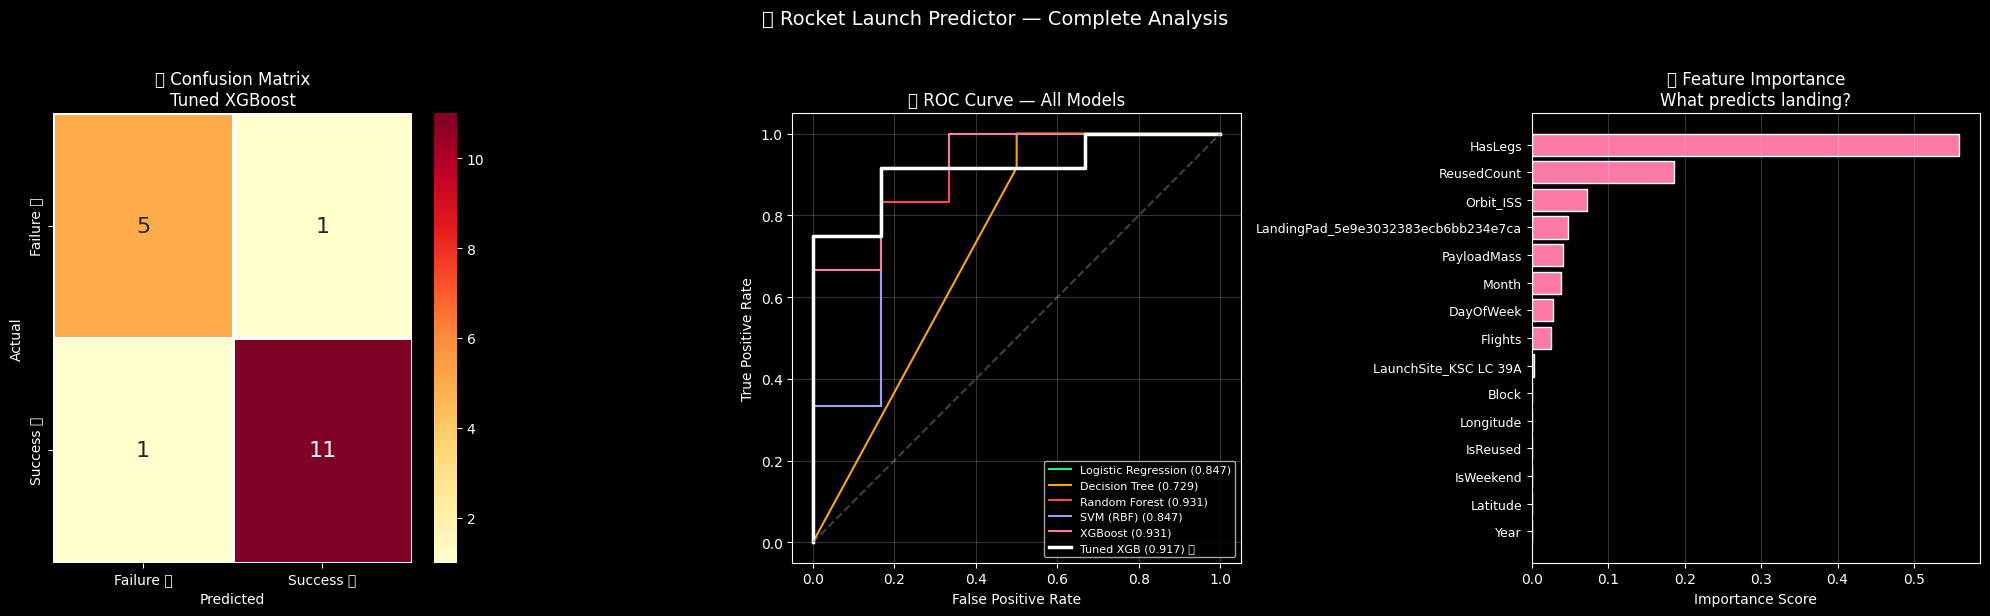


📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     Failure       0.83      0.83      0.83         6
     Success       0.92      0.92      0.92        12

    accuracy                           0.89        18
   macro avg       0.88      0.88      0.88        18
weighted avg       0.89      0.89      0.89        18



In [10]:
# ============================================================
# CELL 6: Confusion Matrix, ROC & Feature Importance
# ============================================================

cm = confusion_matrix(y_test, y_pred_t)
tn, fp, fn, tp = cm.ravel()

print(f"🚀 ROCKET LANDING RESULTS:")
print(f"   ✅ Failures correctly predicted : {tn}")
print(f"   ✅ Successes correctly predicted: {tp}")
print(f"   🚨 Failures MISSED              : {fn}")
print(f"   ⚠️  False alarms                 : {fp}")
print(f"\n   Failure catch rate: {tn/(tn+fp)*100:.2f}%"
      f" ← saving $60M per caught failure!")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d',
            cmap='YlOrRd',
            xticklabels=['Failure ❌', 'Success ✅'],
            yticklabels=['Failure ❌', 'Success ✅'],
            linewidths=2,
            annot_kws={'size': 16},
            ax=axes[0])
axes[0].set_title('🚀 Confusion Matrix\nTuned XGBoost',
                   fontsize=12)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
colors = ['#00ff88','#ffa502','#ff4757',
          '#a29bfe','#fd79a8']
for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    axes[1].plot(fpr, tpr, color=color,
                 linewidth=1.5,
                 label=f"{name} ({r['auc']:.3f})")

fpr_t, tpr_t, _ = roc_curve(y_test, y_proba_t)
axes[1].plot(fpr_t, tpr_t, color='white',
             linewidth=2.5,
             label=f"Tuned XGB ({tuned_auc:.3f}) 🏆")
axes[1].plot([0,1],[0,1],'--',
             color='gray', alpha=0.5)
axes[1].set_title('🚀 ROC Curve — All Models',
                   fontsize=12)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2)

# Feature Importance
xgb_model    = best_model.named_steps['model']
prep_fitted  = best_model.named_steps['prep']

try:
    cat_enc      = (prep_fitted
                    .named_transformers_['cat']
                    .named_steps['encoder'])
    cat_features = cat_enc.get_feature_names_out(
                   cat_cols).tolist()
except:
    cat_features = []

all_features = num_cols + cat_features
importances  = xgb_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature'   : all_features[:len(importances)],
    'Importance': importances
}).sort_values('Importance',
               ascending=False).head(15)

axes[2].barh(range(len(feat_df)),
             feat_df['Importance'].values[::-1],
             color='#fd79a8', edgecolor='white')
axes[2].set_yticks(range(len(feat_df)))
axes[2].set_yticklabels(
    feat_df['Feature'].values[::-1], fontsize=9)
axes[2].set_title('🚀 Feature Importance\nWhat predicts landing?',
                   fontsize=12)
axes[2].set_xlabel('Importance Score')
axes[2].grid(axis='x', alpha=0.2)

plt.suptitle('🚀 Rocket Launch Predictor — Complete Analysis',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_t,
      target_names=['Failure', 'Success']))

In [11]:
# ============================================================
# CELL 7: Final Summary
# ============================================================

print("=" * 65)
print("🚀 ROCKET LAUNCH PREDICTOR — PROJECT COMPLETE!")
print("=" * 65)

print(f"""
📋 PROJECT OVERVIEW:
   Dataset  : SpaceX Falcon 9 Launch Records
   Launches : {df.shape[0]} real missions
   Task     : Predict booster landing success/failure
   Built by : Kartik | Munich | 2025

🎯 WHY RECALL MATTERS HERE:
   Missing a failure prediction = $60M rocket crashes!
   False alarm = extra checks (cheap!)
   → RECALL for failures is our critical metric!
""")

print("📊 ALL MODELS COMPARISON:")
print("=" * 65)
print(f"   {'Model':22} {'Test Acc':10} {'Recall':10}"
      f" {'AUC':10} {'CV AUC'}")
print("-" * 60)
for name, r in results.items():
    print(f"   {name:22} {r['test']:10.4f}"
          f" {r['recall']:10.4f}"
          f" {r['auc']:10.4f}"
          f" {r['cv']:10.4f}")
print(f"   {'Tuned XGBoost':22} {tuned_acc:10.4f}"
      f" {tuned_rec:10.4f}"
      f" {tuned_auc:10.4f} 🏆")

print(f"""
🚨 CRITICAL RESULTS:
   Failures correctly predicted: {tn} ✅
   Failures MISSED             : {fn} 🚨
   False alarms                : {fp} ⚠️

⚡ FEATURE ENGINEERING IMPACT:
   Created 12 aerospace domain features
   Year, IsReused, MatureBlock, HeavyPayload etc.
   Domain knowledge → better predictions!

🚀 PHASE 2 SKILLS DEMONSTRATED:
   ✅ Full Pipeline + ColumnTransformer
   ✅ Feature Engineering (aerospace domain!)
   ✅ 5 models compared head-to-head
   ✅ GridSearch inside Pipeline
   ✅ Recall optimisation for failures
   ✅ ROC curve + confusion matrix
   ✅ Feature importance analysis
   ✅ Real SpaceX mission data!

🌍 REAL WORLD IMPACT:
   SpaceX saves ~$60M per successful landing!
   Predicting failures helps mission planning
   This exact ML approach is used in
   aerospace reliability engineering!
""")

print("=" * 65)
print("✅ PROJECT 3 COMPLETE — READY FOR PORTFOLIO!")
print("=" * 65)
print()
print("📈 PHASE 2 PORTFOLIO:")
print("   ✅ Project 1 — Stellar Classification (98%!) 🌌")
print("   ✅ Project 2 — Fraud Detection (90.82% recall!) 💳")
print("   ✅ Project 3 — Rocket Launch Predictor 🚀")
print("   ⬜ Project 4 — Drug Discovery")
print("   ⬜ Project 5 — Climate Change Predictor")
print("=" * 65)

🚀 ROCKET LAUNCH PREDICTOR — PROJECT COMPLETE!

📋 PROJECT OVERVIEW:
   Dataset  : SpaceX Falcon 9 Launch Records
   Launches : 90 real missions
   Task     : Predict booster landing success/failure
   Built by : Kartik | Munich | 2025

🎯 WHY RECALL MATTERS HERE:
   Missing a failure prediction = $60M rocket crashes!
   False alarm = extra checks (cheap!)
   → RECALL for failures is our critical metric!

📊 ALL MODELS COMPARISON:
   Model                  Test Acc   Recall     AUC        CV AUC
------------------------------------------------------------
   Logistic Regression        0.8889     0.9167     0.8472     0.8722
   Decision Tree              0.8333     1.0000     0.7292     0.7972
   Random Forest              0.8333     1.0000     0.9306     0.8958
   SVM (RBF)                  0.7778     1.0000     0.8472     0.8556
   XGBoost                    0.8889     0.9167     0.9306     0.8889
   Tuned XGBoost              0.8889     0.9167     0.9167 🏆

🚨 CRITICAL RESULTS:
   Failure